<a href="https://colab.research.google.com/github/tejas883/Roll_No_32_Machine-Learning-Lab/blob/main/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Tejas Surendra Mule

Batch :CS2


Roll Number : CS32



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:

# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Upload the dataset in Google Colab
from google.colab import files

uploaded = files.upload()

# Load the uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display the first five rows
print("First five rows of the dataset:")
display(df.head())

# Display dataset shape
print("\nDataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Saving archive (7).zip to archive (7).zip
First five rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Dataset Shape: (569, 33)

Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 no

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

First five rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Dataset Shape:
(569, 33)

Column Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactne

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Diagnosis Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis Class Distribution (%):
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


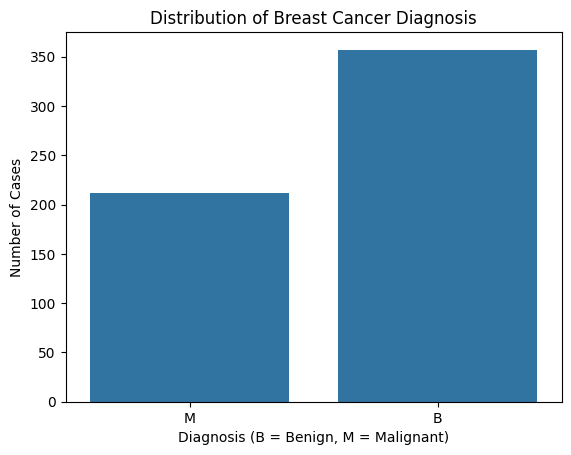

In [ ]:

# Task 2: Explore the Dataset

# 1. Display the first five rows
print("First five rows:")
display(df.head())

# 2. Check dataset shape
print("\nDataset Shape:")
print(df.shape)

# 3. Check column data types
print("\nColumn Data Types:")
print(df.dtypes)

# 4. Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# 5. Calculate total missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

# 6. Display summary statistics
print("\nSummary Statistics:")
display(df.describe())

# 7. Check target class distribution
print("\nDiagnosis Class Distribution:")
print(df["diagnosis"].value_counts())

# 8. Display class distribution in percentage
print("\nDiagnosis Class Distribution (%):")
print(df["diagnosis"].value_counts(normalize=True) * 100)

# 9. Visualize diagnosis distribution
sns.countplot(data=df, x="diagnosis")
plt.title("Distribution of Breast Cancer Diagnosis")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Number of Cases")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:

# Task 3: Data Cleaning and Feature/Target Selection

# 1. Drop unnecessary metadata columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# 2. Convert diagnosis into numerical values
# M = 1 (Malignant), B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# 3. Separate features (X) and target (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# 4. Display the results
print("Feature Matrix (X):")
display(X.head())

print("\nTarget Vector (y):")
print(y.head())

# 5. Check dimensions
print("\nFeature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

# 6. Check target values
print("\nTarget Class Distribution:")
print(y.value_counts())

Feature Matrix (X):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Vector (y):
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

Feature Matrix Shape: (569, 30)
Target Vector Shape: (569,)

Target Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:

# Task 4: Standardize Features

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

# Convert scaled data into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Display first five rows
print("First five rows of standardized features:")
display(X_scaled.head())

# Check mean of each feature
print("\nMean of standardized features:")
print(X_scaled.mean().round(4))

# Check standard deviation of each feature
print("\nStandard deviation of standardized features:")
print(X_scaled.std(ddof=0).round(4))

# Check shape
print("\nShape of standardized data:", X_scaled.shape)

First five rows of standardized features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



Mean of standardized features:
radius_mean               -0.0
texture_mean               0.0
perimeter_mean            -0.0
area_mean                 -0.0
smoothness_mean           -0.0
compactness_mean           0.0
concavity_mean             0.0
concave points_mean       -0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                -0.0
perimeter_se              -0.0
area_se                   -0.0
smoothness_se             -0.0
compactness_se             0.0
concavity_se               0.0
concave points_se          0.0
symmetry_se                0.0
fractal_dimension_se      -0.0
radius_worst              -0.0
texture_worst              0.0
perimeter_worst           -0.0
area_worst                 0.0
smoothness_worst          -0.0
compactness_worst         -0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst             0.0
fractal_dimension_worst   -0.0
dtype: float64

Standard deviation of 

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:

# Task 5: Implement PCA (30D to 2D)

from sklearn.decomposition import PCA

# Create PCA object with 2 principal components
pca = PCA(n_components=2)

# Transform 30-dimensional data into 2-dimensional data
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

# Display first five rows
print("First five rows of PCA-transformed data:")
display(pca_df.head())

# Display shape of transformed data
print("\nOriginal feature shape:", X_scaled.shape)
print("PCA-transformed shape:", X_pca.shape)

# Display explained variance ratio
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Display total variance retained by two components
print("\nTotal Variance Retained:")
print(round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

First five rows of PCA-transformed data:


,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072



Original feature shape: (569, 30)
PCA-transformed shape: (569, 2)

Explained Variance Ratio:
[0.44272026 0.18971182]

Total Variance Retained:
63.24 %


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:

# Task 6: Analyze Explained Variance Ratio

# Calculate variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

# Calculate cumulative variance retained
cumulative_variance = np.cumsum(explained_variance)

# Print individual explained variance
print("Variance Explained by PC1: {:.2f}%".format(
    explained_variance[0] * 100
))

print("Variance Explained by PC2: {:.2f}%".format(
    explained_variance[1] * 100
))

# Print cumulative variance
print("Cumulative Variance Retained by PC1: {:.2f}%".format(
    cumulative_variance[0] * 100
))

print("Cumulative Variance Retained by PC1 and PC2: {:.2f}%".format(
    cumulative_variance[1] * 100
))

# Display values in a table
variance_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

print("\nExplained Variance Summary:")
display(variance_df.round(2))

Variance Explained by PC1: 44.27%
Variance Explained by PC2: 18.97%
Cumulative Variance Retained by PC1: 44.27%
Cumulative Variance Retained by PC1 and PC2: 63.24%

Explained Variance Summary:


,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,44.27,44.27
1,PC2,18.97,63.24


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

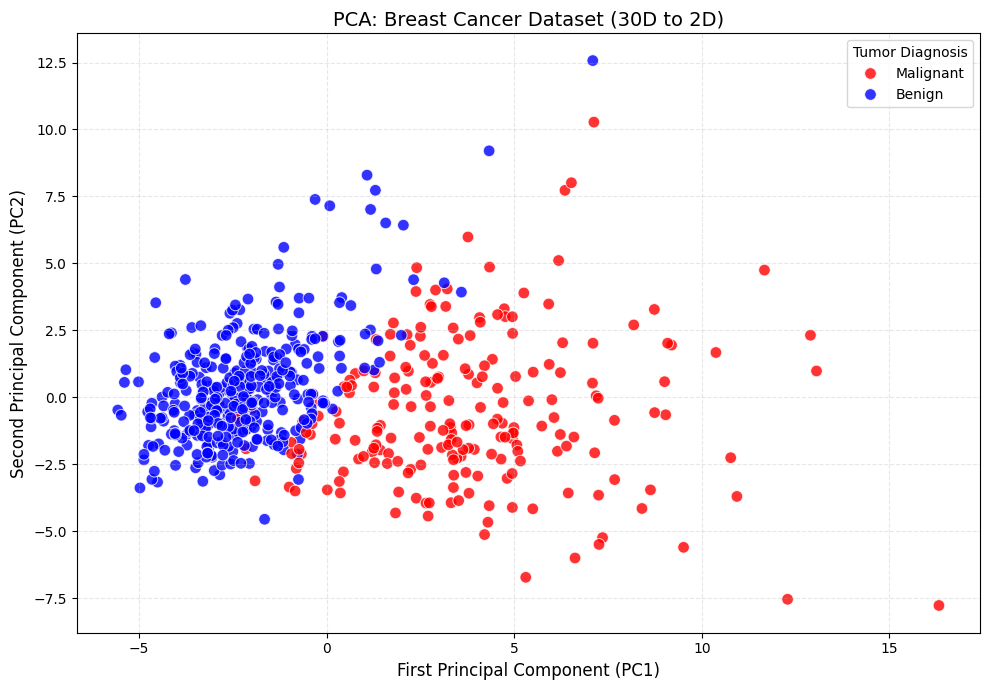

In [ ]:

# Task 7: Visualize PCA Transformed Data

# Add diagnosis labels to PCA DataFrame
pca_df["diagnosis"] = y.map({
    0: "Benign",
    1: "Malignant"
})

# Create the 2D scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="diagnosis",
    palette={
        "Benign": "blue",
        "Malignant": "red"
    },
    s=70,
    alpha=0.8
)

# Add title and labels
plt.title("PCA: Breast Cancer Dataset (30D to 2D)", fontsize=14)
plt.xlabel("First Principal Component (PC1)", fontsize=12)
plt.ylabel("Second Principal Component (PC2)", fontsize=12)

plt.legend(title="Tumor Diagnosis")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:

# Task 8: Logistic Regression on Original 30 Features

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Split the original scaled dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create and train Logistic Regression model
lr_raw = LogisticRegression(max_iter=10000)
lr_raw.fit(X_train, y_train)

# Predict on test data
y_pred_raw = lr_raw.predict(X_test)

# Calculate baseline accuracy
raw_accuracy = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression on Original 30 Features")
print("-" * 45)
print(f"Accuracy: {raw_accuracy * 100:.2f}%")

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

# Display classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Benign", "Malignant"]
))

Logistic Regression on Original 30 Features
---------------------------------------------
Accuracy: 96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:

# Task 9: Logistic Regression on PCA Transformed Data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Split the 2D PCA dataset into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
lr_pca = LogisticRegression(max_iter=10000)

# Train the model using only PC1 and PC2
lr_pca.fit(X_train_pca, y_train_pca)

# Predict test data
y_pred_pca = lr_pca.predict(X_test_pca)

# Calculate accuracy
pca_accuracy = accuracy_score(y_test_pca, y_pred_pca)

print("Logistic Regression on PCA Data (2 Features)")
print("-" * 45)
print(f"Accuracy: {pca_accuracy * 100:.2f}%")

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

# Display classification report
print("\nClassification Report:")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

# Display feature dimensions
print("\nOriginal number of features:", X_scaled.shape[1])
print("PCA number of features:", X_pca.shape[1])

Logistic Regression on PCA Data (2 Features)
---------------------------------------------
Accuracy: 93.86%

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


Original number of features: 30
PCA number of features: 2


# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



Accuracy Comparison
----------------------------------------
Before PCA (30 features): 96.49%
After PCA (2 components): 93.86%

Accuracy Table:


,Model,Accuracy (%)
0,Logistic Regression (30 Features),96.49
1,Logistic Regression (2 PCA Components),93.86



Confusion Matrix Before PCA:
[[71  1]
 [ 3 39]]

Confusion Matrix After PCA:
[[71  1]
 [ 6 36]]


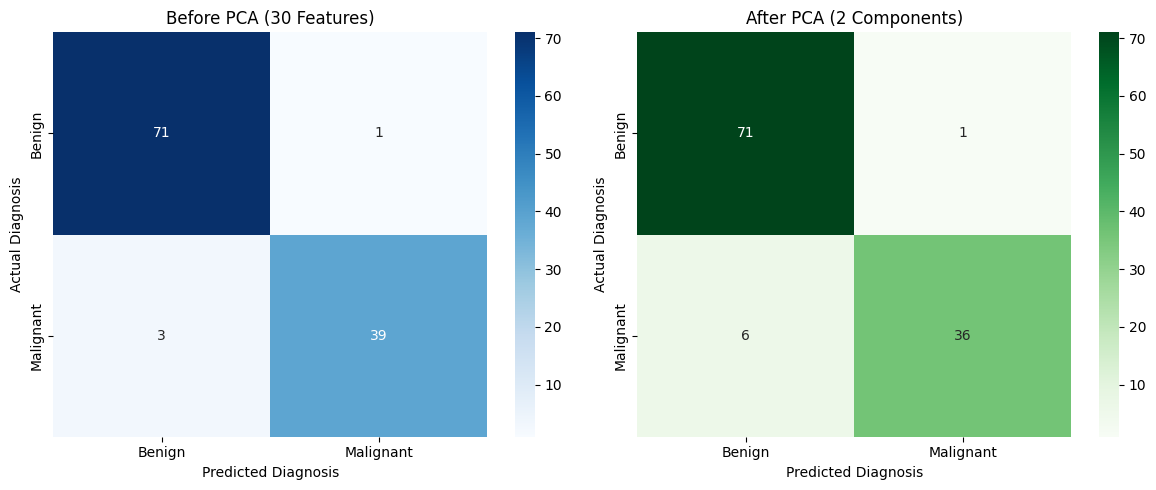


Classification Report Before PCA:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report After PCA:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


Weighted-Average Performance Comparison:


,Metric,Before PCA (30 Features),After PCA (2 Components)
0,Precision,0.9652,0.9408
1,Recall,0.9649,0.9386
2,F1-Score,0.9647,0.9377


In [ ]:

# Task 10: Compare Classifier Performance

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy scores
raw_accuracy = accuracy_score(y_test, y_pred_raw)
pca_accuracy = accuracy_score(y_test_pca, y_pred_pca)

print("Accuracy Comparison")
print("-" * 40)
print(f"Before PCA (30 features): {raw_accuracy * 100:.2f}%")
print(f"After PCA (2 components): {pca_accuracy * 100:.2f}%")

# Create accuracy comparison table
accuracy_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (30 Features)",
        "Logistic Regression (2 PCA Components)"
    ],
    "Accuracy (%)": [
        raw_accuracy * 100,
        pca_accuracy * 100
    ]
})

print("\nAccuracy Table:")
display(accuracy_df.round(2))

# Confusion matrix before PCA
cm_raw = confusion_matrix(y_test, y_pred_raw)

print("\nConfusion Matrix Before PCA:")
print(cm_raw)

# Confusion matrix after PCA
cm_pca = confusion_matrix(y_test_pca, y_pred_pca)

print("\nConfusion Matrix After PCA:")
print(cm_pca)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_raw, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[0]
)
axes[0].set_title("Before PCA (30 Features)")
axes[0].set_xlabel("Predicted Diagnosis")
axes[0].set_ylabel("Actual Diagnosis")

sns.heatmap(
    cm_pca, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[1]
)
axes[1].set_title("After PCA (2 Components)")
axes[1].set_xlabel("Predicted Diagnosis")
axes[1].set_ylabel("Actual Diagnosis")

plt.tight_layout()
plt.show()

# Classification report before PCA
print("\nClassification Report Before PCA:")
print(classification_report(
    y_test, y_pred_raw,
    target_names=["Benign", "Malignant"],
    zero_division=0
))

# Classification report after PCA
print("\nClassification Report After PCA:")
print(classification_report(
    y_test_pca, y_pred_pca,
    target_names=["Benign", "Malignant"],
    zero_division=0
))

# Extract precision, recall, and F1-score for both models
report_raw = classification_report(
    y_test, y_pred_raw,
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

report_pca = classification_report(
    y_test_pca, y_pred_pca,
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

# Compare weighted-average metrics
comparison_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Before PCA (30 Features)": [
        report_raw["weighted avg"]["precision"],
        report_raw["weighted avg"]["recall"],
        report_raw["weighted avg"]["f1-score"]
    ],
    "After PCA (2 Components)": [
        report_pca["weighted avg"]["precision"],
        report_pca["weighted avg"]["recall"],
        report_pca["weighted avg"]["f1-score"]
    ]
})

print("\nWeighted-Average Performance Comparison:")
display(comparison_df.round(4))

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.